Visualizations to understand what is done in simulate.py

In [2]:
# importations
# public
import numpy as np
import matplotlib.pyplot as plt

# local
from dual_spls.simulate import simulate

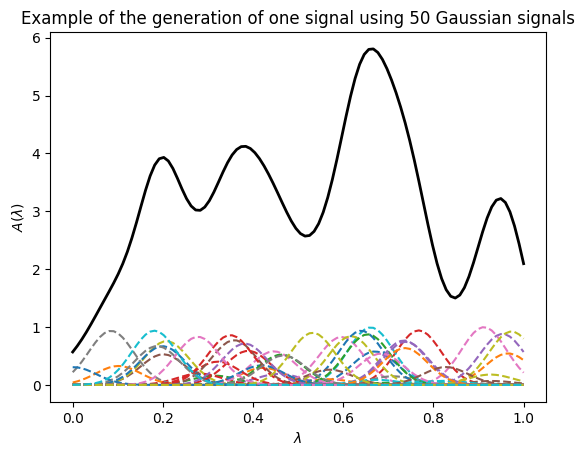

In [3]:
# one signal

p = 100
nondes = 50
sigmaondes = 0.05

x_local = np.linspace(0, 1, p)
amplitudes = np.random.uniform(0, 1, nondes)
modes = np.random.uniform(0, 1, nondes)

signal = np.zeros(p)
for j in range(nondes):
    gauss = amplitudes[j] * np.exp(-(x_local - modes[j])**2 / (2 * sigmaondes**2))  
    signal += gauss

    plt.plot(x_local, gauss, "--")

plt.xlabel("$\lambda$")
plt.ylabel("$A(\lambda)$")
plt.title("Example of the generation of one signal using 50 Gaussian signals")
plt.plot(x_local, signal, "k-", linewidth=2, label="Total Signal")
plt.show()


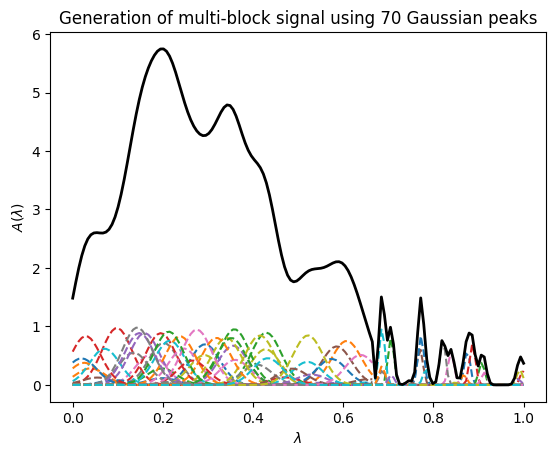

In [4]:
# generate len(p) signals to be concatenated:
p = [100, 50]
nondes = [50, 20]
sigmaondes = [0.05, 0.02]

begin = 0
signal = np.zeros(sum(p))
x_full  = np.linspace(0, 1, sum(p))
for k in range(len(p)):
    # generation of random amplitudes and mode for the gaussians
    current_x_range = x_full[begin : begin + p[k]]
    x_local = np.linspace(0, 1, p[k])
    amplitudes = np.random.uniform(0, 1, nondes[k])
    modes = np.random.uniform(0, 1, nondes[k])

    # build signal
    for j in range(nondes[k]):
        gauss = amplitudes[j] * np.exp(-(x_local - modes[j])**2 / (2 * sigmaondes[k]**2)) 
        signal[begin: begin+p[k]] += gauss

        plt.plot(current_x_range, gauss, "--")
        
    begin += p[k] # shift of p[k] to be able to concatenate the signals in the next iteration

plt.xlabel("$\lambda$")
plt.ylabel("$A(\lambda)$")
plt.title(f"Generation of multi-block signal using {sum(nondes)} Gaussian peaks")
plt.plot(x_full, signal, "k-", linewidth=2, label="Total Signal")
plt.show()

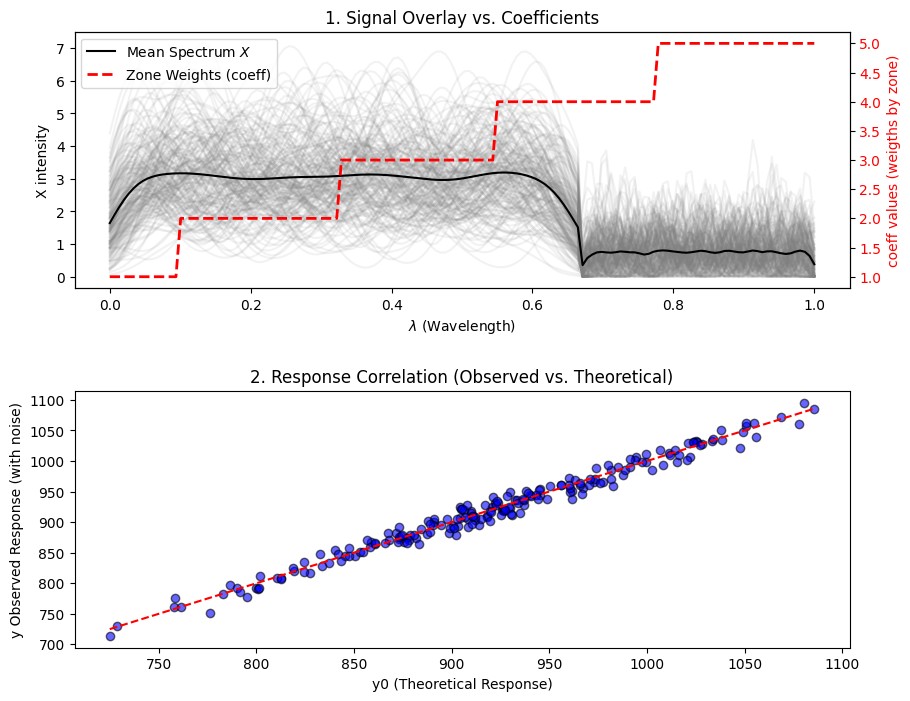

In [5]:
# Retrieve data
p = [100, 50]
p_total = np.sum(p)  # 100 + 50
x_full = np.linspace(0, 1, p_total)

coefs = [1, 2, 3, 4, 5]

# use the library to simulate n*len(p) signals
results = simulate(n=200, p=p, nondes=[50, 30], sigmaondes=[0.05, 0.02], sigma_y=10, coefs=coefs)
X = results["X"]

# setting the interval limits for y0
limits_pct = np.linspace(10, 100, len(coefs))
pif = np.round(limits_pct * np.sum(p) / 100).astype(int)
pif = np.insert(pif, 0, 0) # pif = [0, linspace(10, len(100))*np.sum(p)] = [0, 10*np.sum(p)/100, ..., np.sum(p)]

x_coefs = np.zeros(np.sum(p))
for i in range(len(pif)-1):
    start_idx = pif[i]
    end_idx = pif[i+1]
    x_coefs[start_idx:end_idx] = coefs[i]

######################################################
# Graphics:
######################################################
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plt.subplots_adjust(hspace=0.4)

######################################################
# 1. Show signal, mean signal, coefficients applied to each zones of lambdas
ax1 = axes[0]
ax1.plot(x_full, X.T, color='gray', alpha=0.1)
ax1.plot(x_full, X.mean(axis=0), color='black', linewidth=1.5, label="Mean Spectrum $X$")
ax1.set_xlabel(r"$\lambda$ (Wavelength)")
ax1.set_ylabel("X intensity")
ax1.set_title("1. Signal Overlay vs. Coefficients")


ax2 = ax1.twinx()
ax2.plot(x_full, x_coefs, color='red', linewidth=2, linestyle='--', label=r"Zone Weights (coeff)")
ax2.set_ylabel(r"coeff values (weigths by zone)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Légendes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

######################################################
# 1. Show y0 (without noise) vs. y (with noise)
ax3 = axes[1]
y = results["y"]
y0 = results["sumX"] @ coefs

ax3.scatter(y0, y, alpha=0.6, c='blue', edgecolor='k')
ax3.plot([y0.min(), y0.max()], [y0.min(), y0.max()], 'r--')
ax3.set_xlabel("y0 (Theoretical Response)")
ax3.set_ylabel("y Observed Response (with noise)")
ax3.set_title("2. Response Correlation (Observed vs. Theoretical)")

plt.show()




Making something similare to $D_{SIM}$

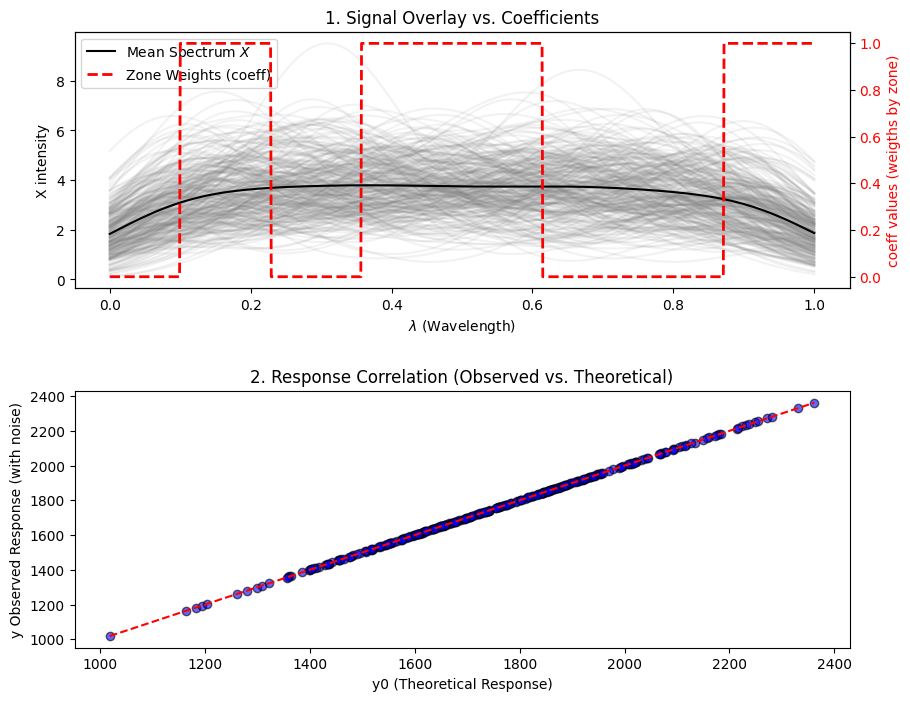

In [14]:
# Retrieve data
p = [1000]
p_total = np.sum(p)  # 100 + 50
x_full = np.linspace(0, 1, p_total)

coefs = [0, 1, 0, 1, 1, 0, 0, 1]

# use the library to simulate n*len(p) signals
results = simulate(n=300, p=p, nondes=[30], sigmaondes=[0.10], sigma_y=1., coefs=coefs)
X = results["X"]

# setting the interval limits for y0
limits_pct = np.linspace(10, 100, len(coefs))
pif = np.round(limits_pct * np.sum(p) / 100).astype(int)
pif = np.insert(pif, 0, 0) # pif = [0, linspace(10, len(100))*np.sum(p)] = [0, 10*np.sum(p)/100, ..., np.sum(p)]

x_coefs = np.zeros(np.sum(p))
for i in range(len(pif)-1):
    start_idx = pif[i]
    end_idx = pif[i+1]
    x_coefs[start_idx:end_idx] = coefs[i]

######################################################
# Graphics:
######################################################
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plt.subplots_adjust(hspace=0.4)

######################################################
# 1. Show signal, mean signal, coefficients applied to each zones of lambdas
ax1 = axes[0]
ax1.plot(x_full, X.T, color='gray', alpha=0.1)
ax1.plot(x_full, X.mean(axis=0), color='black', linewidth=1.5, label="Mean Spectrum $X$")
ax1.set_xlabel(r"$\lambda$ (Wavelength)")
ax1.set_ylabel("X intensity")
ax1.set_title("1. Signal Overlay vs. Coefficients")


ax2 = ax1.twinx()
ax2.plot(x_full, x_coefs, color='red', linewidth=2, linestyle='--', label=r"Zone Weights (coeff)")
ax2.set_ylabel(r"coeff values (weigths by zone)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Légendes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

######################################################
# 1. Show y0 (without noise) vs. y (with noise)
ax3 = axes[1]
y = results["y"]
y0 = results["sumX"] @ coefs

ax3.scatter(y0, y, alpha=0.6, c='blue', edgecolor='k')
ax3.plot([y0.min(), y0.max()], [y0.min(), y0.max()], 'r--')
ax3.set_xlabel("y0 (Theoretical Response)")
ax3.set_ylabel("y Observed Response (with noise)")
ax3.set_title("2. Response Correlation (Observed vs. Theoretical)")

plt.show()